In [66]:
import pandas as pd
import numpy as np 
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

In [80]:
# setup and feature engineering
df = pd.read_csv('../../data/processed/neighborhood_equity_model.csv')

# set neighborhood as index so removed from feature columns
df.set_index("neighborhood", inplace=True)

# select feature columns and scale
X = df.drop(columns=["avgOverallEquityScore"])

# target column - unscaled
target_col = 'avgOverallEquityScore'
y = df[target_col].round().astype(int).values

# only one instance with class 5 so merge with class 4:
y[y == 5] = 4

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# scale full X
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

In [33]:
import numpy as np

classes, counts = np.unique(y, return_counts=True)

for cls, count in zip(classes, counts):
    print(f"Class {cls}: {count} instances")

Class 2: 28 instances
Class 3: 21 instances
Class 4: 29 instances


In [34]:
_, train_counts = np.unique(y_train, return_counts=True)
_, test_counts = np.unique(y_test, return_counts=True)
print("Train distribution:", dict(zip(classes, train_counts)))
print("Test distribution:", dict(zip(classes, test_counts)))

Train distribution: {2: 22, 3: 17, 4: 23}
Test distribution: {2: 6, 3: 4, 4: 6}


## Logistic Regression Models

These models will use both the train/test split data, as well as the complete data set with cross_val_score to evaluate.

### Basic Logistic Regression without Regularization

In [35]:
# with trian_test_split
log_reg = LogisticRegression(max_iter=1000, penalty=None)

log_reg.fit(X_train_scaled, y_train)

# predict on the test set
y_pred = log_reg.predict(X_test_scaled)

# evaluate performance
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Confusion Matrix:
[[4 2 0]
 [1 3 0]
 [0 4 2]]

Classification Report:
              precision    recall  f1-score   support

           2       0.80      0.67      0.73         6
           3       0.33      0.75      0.46         4
           4       1.00      0.33      0.50         6

    accuracy                           0.56        16
   macro avg       0.71      0.58      0.56        16
weighted avg       0.76      0.56      0.58        16



In [36]:
# coefficients
coef_df = pd.DataFrame(
    log_reg.coef_,
    columns=X.columns,
    index=[f"Class {tier}" for tier in log_reg.classes_]
)
coef_df

,Percent Hispanic,Percent White,Percent Black,Percent Native American,Percent Asian,Percent Hawaiian/Pacific Islander,Percent Other Race,Percent Two or More Races,Median Household Income,Per Capita Income,Median Home Value,Percent Living in Poverty,population_density,percent_less_hs,percent_at_hs,percent_some_college,percent_bachelors,program_count_per1000,crime_per1000
Class 2,7.071755,-7.045656,4.262752,-0.363210,-13.820211,18.055444,9.583065,-4.046678,-9.964420,-2.296652,3.143089,10.602233,5.430135,2.785238,5.914873,-7.672859,-1.359173,-10.190467,1.665068
Class 3,-1.062803,0.064629,0.091005,1.721347,3.595646,-16.480431,0.787150,8.879386,1.569307,0.219416,-10.137990,4.396055,6.329766,3.164044,0.913539,-2.385068,-1.143418,7.027379,-0.860382
Class 4,-6.008952,6.981027,-4.353757,-1.358137,10.224565,-1.575013,-10.370215,-4.832708,8.395113,2.077236,6.994901,-14.998289,-11.759901,-5.949282,-6.828413,10.057928,2.502592,3.163088,-0.804685


In [37]:
# feature importance
feature_importance = coef_df.abs().sum(axis=0).sort_values(ascending=False)
print(feature_importance)

Percent Hawaiian/Pacific Islander    36.110888
Percent Living in Poverty            29.996577
Percent Asian                        27.640422
population_density                   23.519803
Percent Other Race                   20.740431
program_count_per1000                20.380934
Median Home Value                    20.275979
percent_some_college                 20.115855
Median Household Income              19.928840
Percent Two or More Races            17.758771
Percent Hispanic                     14.143509
Percent White                        14.091312
percent_at_hs                        13.656825
percent_less_hs                      11.898564
Percent Black                         8.707514
percent_bachelors                     5.005183
Per Capita Income                     4.593304
Percent Native American               3.442694
crime_per1000                         3.330135
dtype: float64


In [38]:
# with cross_val_score
log_reg_cv = LogisticRegression(max_iter=1000, penalty=None)
scores = cross_val_score(log_reg_cv, X_scaled, y, cv=5, scoring='f1_macro')
print("F1 scores:", scores)
print("Mean F1:", scores.mean())

F1 scores: [0.68080808 0.55218855 0.71904762 0.92207792 0.6031746 ]
Mean F1: 0.6954593554593556


### Logistic Regression with L1 Regularization

In [39]:
lasso = LogisticRegression(max_iter=10000, penalty='l1', C=0.5, solver='saga')

lasso.fit(X_train_scaled, y_train)

# predict on the test set
y_pred = lasso.predict(X_test_scaled)

# evaluate performance
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Confusion Matrix:
[[5 1 0]
 [1 2 1]
 [1 1 4]]

Classification Report:
              precision    recall  f1-score   support

           2       0.71      0.83      0.77         6
           3       0.50      0.50      0.50         4
           4       0.80      0.67      0.73         6

    accuracy                           0.69        16
   macro avg       0.67      0.67      0.67        16
weighted avg       0.69      0.69      0.69        16



In [40]:
# coefficients
coef_df = pd.DataFrame(
    lasso.coef_,  
    columns=X.columns,    
    index=[f"Class {tier}" for tier in lasso.classes_]
)
coef_df

,Percent Hispanic,Percent White,Percent Black,Percent Native American,Percent Asian,Percent Hawaiian/Pacific Islander,Percent Other Race,Percent Two or More Races,Median Household Income,Per Capita Income,Median Home Value,Percent Living in Poverty,population_density,percent_less_hs,percent_at_hs,percent_some_college,percent_bachelors,program_count_per1000,crime_per1000
Class 2,0.289179,-0.258460,0.0,0.0,-0.635836,0.649739,0.0,0.000000,0.00000,0.0,0.000000,0.857246,0.000000,0.0,0.244501,0.0,0.0,0.0,0.0
Class 3,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.366373,0.00000,0.0,0.000000,0.000000,0.057458,0.0,0.000000,0.0,0.0,0.0,0.0
Class 4,0.000000,0.748444,0.0,0.0,0.109605,0.000000,0.0,0.000000,0.39001,0.0,1.170152,-0.915681,-0.289536,0.0,0.000000,0.0,0.0,0.0,0.0


In [41]:
# feature importance
feature_importance = coef_df.abs().sum(axis=0).sort_values(ascending=False)
print(feature_importance)

Percent Living in Poverty            1.772927
Median Home Value                    1.170152
Percent White                        1.006904
Percent Asian                        0.745440
Percent Hawaiian/Pacific Islander    0.649739
Median Household Income              0.390010
Percent Two or More Races            0.366373
population_density                   0.346993
Percent Hispanic                     0.289179
percent_at_hs                        0.244501
program_count_per1000                0.000000
percent_bachelors                    0.000000
percent_some_college                 0.000000
Per Capita Income                    0.000000
percent_less_hs                      0.000000
Percent Other Race                   0.000000
Percent Native American              0.000000
Percent Black                        0.000000
crime_per1000                        0.000000
dtype: float64


In [42]:
# with cross_val_score
lasso_cv = LogisticRegression(max_iter=10000, penalty='l1', C=0.5, solver='saga')
scores = cross_val_score(lasso_cv, X_scaled, y, cv=5, scoring='f1_macro')
print("F1 scores:", scores)
print("Mean F1:", scores.mean())

F1 scores: [0.72466422 0.72610723 0.52777778 0.92207792 0.54047619]
Mean F1: 0.6882206682206682


### Logistic Regression with L2 Regularization

In [43]:
ridge = LogisticRegression(max_iter=1000, penalty='l2', C=0.5)

ridge.fit(X_train_scaled, y_train)

# predict on the test set
y_pred = ridge.predict(X_test_scaled)

# evaluate performance
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Confusion Matrix:
[[5 1 0]
 [1 2 1]
 [0 4 2]]

Classification Report:
              precision    recall  f1-score   support

           2       0.83      0.83      0.83         6
           3       0.29      0.50      0.36         4
           4       0.67      0.33      0.44         6

    accuracy                           0.56        16
   macro avg       0.60      0.56      0.55        16
weighted avg       0.63      0.56      0.57        16



In [44]:
# coefficients
coef_df = pd.DataFrame(
    ridge.coef_,  
    columns=X.columns,    
    index=[f"Class {tier}" for tier in ridge.classes_]
)
coef_df

,Percent Hispanic,Percent White,Percent Black,Percent Native American,Percent Asian,Percent Hawaiian/Pacific Islander,Percent Other Race,Percent Two or More Races,Median Household Income,Per Capita Income,Median Home Value,Percent Living in Poverty,population_density,percent_less_hs,percent_at_hs,percent_some_college,percent_bachelors,program_count_per1000,crime_per1000
Class 2,0.409737,-0.388738,0.145301,0.024890,-0.665106,0.622374,0.299777,-0.085792,-0.501932,-0.206718,0.089206,0.760652,0.219324,0.326937,0.303385,-0.155095,-0.234690,-0.230262,0.127280
Class 3,0.002121,-0.087255,0.105169,-0.027629,0.155583,-0.474414,0.057916,0.443085,0.054389,-0.062738,-0.554739,-0.020537,0.291590,0.149018,0.010514,-0.088822,-0.047787,-0.007597,-0.084871
Class 4,-0.411858,0.475993,-0.250470,0.002739,0.509523,-0.147960,-0.357693,-0.357293,0.447543,0.269456,0.465532,-0.740115,-0.510914,-0.475955,-0.313899,0.243917,0.282478,0.237859,-0.042409


In [45]:
# feature importance
feature_importance = coef_df.abs().sum(axis=0).sort_values(ascending=False)
print(feature_importance)

Percent Living in Poverty            1.521304
Percent Asian                        1.330211
Percent Hawaiian/Pacific Islander    1.244749
Median Home Value                    1.109477
population_density                   1.021827
Median Household Income              1.003864
Percent White                        0.951985
percent_less_hs                      0.951910
Percent Two or More Races            0.886170
Percent Hispanic                     0.823716
Percent Other Race                   0.715386
percent_at_hs                        0.627798
percent_bachelors                    0.564956
Per Capita Income                    0.538912
Percent Black                        0.500940
percent_some_college                 0.487833
program_count_per1000                0.475718
crime_per1000                        0.254560
Percent Native American              0.055258
dtype: float64


In [46]:
# with cross_val_score
ridge_cv = LogisticRegression(max_iter=1000, penalty='l2', C=0.5)
scores = cross_val_score(ridge_cv, X_scaled, y, cv=5, scoring='f1_macro')
print("F1 scores:", scores)
print("Mean F1:", scores.mean())

F1 scores: [0.62942613 0.58333333 0.57387057 1.         0.62433862]
Mean F1: 0.6821937321937322


### Logistic Regression with Elasticnet Regularization

In [47]:
elastic = LogisticRegression(max_iter=1000, penalty='elasticnet', l1_ratio=0.5, solver='saga')

elastic.fit(X_train_scaled, y_train)

# predict on the test set
y_pred = elastic.predict(X_test_scaled)

# evaluate performance
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Confusion Matrix:
[[5 1 0]
 [1 2 1]
 [0 4 2]]

Classification Report:
              precision    recall  f1-score   support

           2       0.83      0.83      0.83         6
           3       0.29      0.50      0.36         4
           4       0.67      0.33      0.44         6

    accuracy                           0.56        16
   macro avg       0.60      0.56      0.55        16
weighted avg       0.63      0.56      0.57        16



In [48]:
# coefficients
coef_df = pd.DataFrame(
    elastic.coef_,  
    columns=X.columns,    
    index=[f"Class {tier}" for tier in elastic.classes_]
)
coef_df

,Percent Hispanic,Percent White,Percent Black,Percent Native American,Percent Asian,Percent Hawaiian/Pacific Islander,Percent Other Race,Percent Two or More Races,Median Household Income,Per Capita Income,Median Home Value,Percent Living in Poverty,population_density,percent_less_hs,percent_at_hs,percent_some_college,percent_bachelors,program_count_per1000,crime_per1000
Class 2,0.413239,-0.547653,0.000000,0.0,-0.891693,0.969756,0.209584,0.000000,-0.804804,0.000000,0.000000,1.037753,0.000000,0.084716,0.346656,0.000000,0.000000,-0.142873,0.0
Class 3,0.000000,0.000000,0.000000,0.0,0.000000,-0.436156,0.000000,0.573759,0.000000,0.000000,-0.767978,0.000000,0.026624,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
Class 4,-0.465998,0.811441,-0.172011,0.0,0.524357,0.000000,-0.397988,-0.202939,0.454471,0.045475,0.623652,-1.193568,-0.785216,-0.656835,-0.222445,0.008001,0.004235,0.091225,0.0


In [49]:
# feature importance
feature_importance = coef_df.abs().sum(axis=0).sort_values(ascending=False)
print(feature_importance)

Percent Living in Poverty            2.231321
Percent Asian                        1.416050
Percent Hawaiian/Pacific Islander    1.405912
Median Home Value                    1.391630
Percent White                        1.359094
Median Household Income              1.259274
Percent Hispanic                     0.879238
population_density                   0.811840
Percent Two or More Races            0.776698
percent_less_hs                      0.741551
Percent Other Race                   0.607572
percent_at_hs                        0.569101
program_count_per1000                0.234098
Percent Black                        0.172011
Per Capita Income                    0.045475
percent_some_college                 0.008001
percent_bachelors                    0.004235
Percent Native American              0.000000
crime_per1000                        0.000000
dtype: float64


In [50]:
# with cross_val_score
elastic_cv = LogisticRegression(max_iter=1000, penalty='elasticnet', l1_ratio=0.5, solver='saga')
scores = cross_val_score(elastic_cv, X_scaled, y, cv=5, scoring='f1_macro')
print("F1 scores:", scores)
print("Mean F1:", scores.mean())

F1 scores: [0.72610723 0.58333333 0.57387057 1.         0.6981685 ]
Mean F1: 0.7162959262959263


## Hyperparameter tuning

Using GridSearchCV to find regularization hyperparameters

In [51]:
# setup
model_cv = LogisticRegression(solver='saga', max_iter=10000)

# setting up grid of tunable hyperparameters
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [0.01, 0.1, 0.5, 1, 10],
    'l1_ratio': [0, 0.25, 0.5, 0.75, 1]
}

grid_search = GridSearchCV(
    estimator=model_cv,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    refit=True,
    n_jobs=-1
)

# fit on entire scaled feature columns
grid_search.fit(X_scaled, y)

print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warni

Best params: {'C': 10, 'l1_ratio': 0.5, 'penalty': 'elasticnet'}
Best score: 0.7539675139675139


/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


In [52]:
# model using the hyperparameters found above
elastic_update = LogisticRegression(max_iter=10000, penalty='elasticnet', C=10, l1_ratio=0.5, solver='saga')

elastic_update.fit(X_train_scaled, y_train)

# predict on the test set
y_pred = elastic_update.predict(X_test_scaled)

# evaluate performance
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Confusion Matrix:
[[5 1 0]
 [1 3 0]
 [0 4 2]]

Classification Report:
              precision    recall  f1-score   support

           2       0.83      0.83      0.83         6
           3       0.38      0.75      0.50         4
           4       1.00      0.33      0.50         6

    accuracy                           0.62        16
   macro avg       0.74      0.64      0.61        16
weighted avg       0.78      0.62      0.62        16



In [53]:
# coefficients
coef_df = pd.DataFrame(
    elastic_update.coef_,  
    columns=X.columns,    
    index=[f"Class {tier}" for tier in elastic_update.classes_]
)
coef_df

,Percent Hispanic,Percent White,Percent Black,Percent Native American,Percent Asian,Percent Hawaiian/Pacific Islander,Percent Other Race,Percent Two or More Races,Median Household Income,Per Capita Income,Median Home Value,Percent Living in Poverty,population_density,percent_less_hs,percent_at_hs,percent_some_college,percent_bachelors,program_count_per1000,crime_per1000
Class 2,1.694396,-1.591702,0.208698,0.030386,-2.670754,3.420210,1.578988,-0.786987,-1.840386,-0.062986,0.156231,2.165381,0.661283,0.024667,0.977205,-0.490573,0.00000,-1.730171,0.022736
Class 3,0.000000,0.000000,0.000000,-0.062802,0.429260,-2.503413,0.000000,1.588078,0.191751,0.000000,-2.023574,0.121786,0.579716,0.659375,0.000000,0.000000,0.00000,0.482959,0.000000
Class 4,-1.541830,1.815979,-0.550862,0.000000,1.535763,-0.210923,-1.613031,-0.095445,0.953423,0.557885,1.164661,-2.972498,-1.946882,-1.389248,-0.956673,1.183616,0.39431,0.556312,-0.004250


In [54]:
# feature importance
feature_importance = coef_df.abs().sum(axis=0).sort_values(ascending=False)
print(feature_importance)

Percent Hawaiian/Pacific Islander    6.134547
Percent Living in Poverty            5.259665
Percent Asian                        4.635777
Percent White                        3.407681
Median Home Value                    3.344466
Percent Hispanic                     3.236227
Percent Other Race                   3.192020
population_density                   3.187880
Median Household Income              2.985559
program_count_per1000                2.769441
Percent Two or More Races            2.470510
percent_less_hs                      2.073290
percent_at_hs                        1.933878
percent_some_college                 1.674189
Percent Black                        0.759560
Per Capita Income                    0.620871
percent_bachelors                    0.394310
Percent Native American              0.093187
crime_per1000                        0.026985
dtype: float64


## Model Updates

Updating the feature columns based on the regularization models above

In [81]:
# new feature columns
new_features = ["Percent Living in Poverty", "Median Household Income", "percent_less_hs", "Median Home Value", "Percent Hispanic", "Percent White"]

X = df[new_features]

# target column - unscaled
target_col = 'avgOverallEquityScore'
y = df[target_col].round().astype(int).values

# only one instance with class 5 so merge with class 4:
y[y == 5] = 4

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# scale full X
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

### Using GridSearchCV with new features

In [61]:
# setup
new_model_cv = LogisticRegression(solver='saga', max_iter=10000)

# setting up grid of tunable hyperparameters
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [0.01, 0.1, 0.5, 1, 10],
    'l1_ratio': [0, 0.25, 0.5, 0.75, 1]
}

grid_search = GridSearchCV(
    estimator=new_model_cv,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    refit=True,
    n_jobs=-1
)

# fit on entire scaled feature columns
grid_search.fit(X_scaled, y)

print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warni

Best params: {'C': 1, 'l1_ratio': 0.25, 'penalty': 'elasticnet'}
Best score: 0.7532678432678434


/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warni

In [62]:
# final model with the hyperparameters above
new_elastic_update = LogisticRegression(max_iter=10000, penalty='elasticnet', C=1, l1_ratio=0.25, solver='saga')

new_elastic_update.fit(X_train_scaled, y_train)

# predict on the test set
y_pred = new_elastic_update.predict(X_test_scaled)

# evaluate performance
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Confusion Matrix:
[[6 0 0]
 [0 1 3]
 [2 1 3]]

Classification Report:
              precision    recall  f1-score   support

           2       0.75      1.00      0.86         6
           3       0.50      0.25      0.33         4
           4       0.50      0.50      0.50         6

    accuracy                           0.62        16
   macro avg       0.58      0.58      0.56        16
weighted avg       0.59      0.62      0.59        16



In [63]:
# coefficients
coef_df = pd.DataFrame(
    new_elastic_update.coef_,  
    columns=X.columns,    
    index=[f"Class {tier}" for tier in new_elastic_update.classes_]
)
coef_df

,Percent Living in Poverty,Median Household Income,percent_less_hs,Median Home Value,Percent Hispanic,Percent White
Class 2,1.154009,-1.091405,0.544076,0.013810,0.900847,-0.153247
Class 3,0.000000,0.000000,0.000000,-1.007419,-0.188604,-0.071386
Class 4,-1.427850,0.855103,-0.729878,0.668774,-0.385029,0.552005


In [64]:
# feature importance
feature_importance = coef_df.abs().sum(axis=0).sort_values(ascending=False)
print(feature_importance)

Percent Living in Poverty    2.581859
Median Household Income      1.946508
Median Home Value            1.690003
Percent Hispanic             1.474479
percent_less_hs              1.273954
Percent White                0.776638
dtype: float64


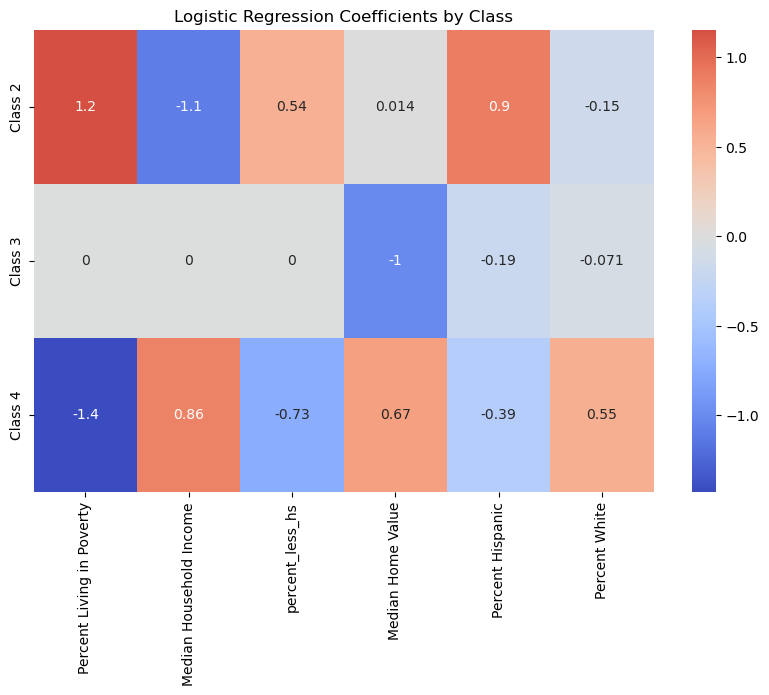

In [67]:
plt.figure(figsize=(10, 6))
sns.heatmap(coef_df, cmap="coolwarm", center=0, annot=True)
plt.title("Logistic Regression Coefficients by Class")
plt.show()

<Axes: >

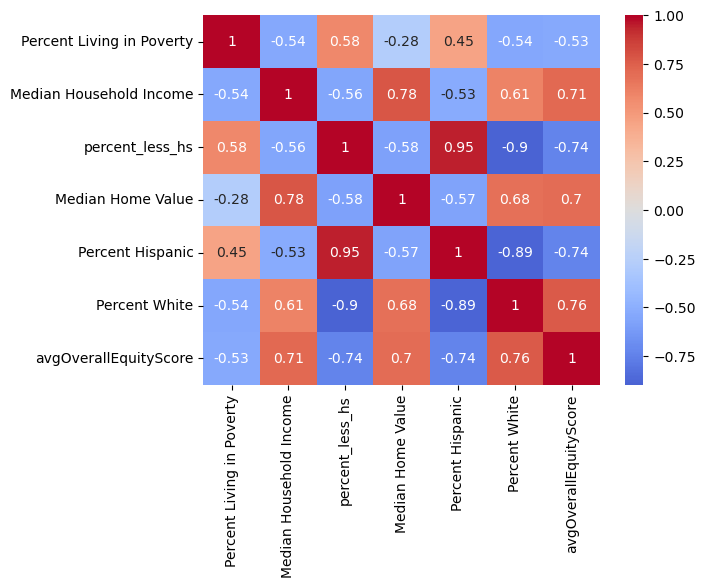

In [82]:
# correlation check with output variable
new_features.append('avgOverallEquityScore')
corr_matrix = df_original[new_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)